# Use of Force Rates by County

Compares NJ Use of Force incident rates between counties, normalized by **population** and **geographic area**.

**Data sources loaded in Part 1:**
1. `uof_main_data` (MySQL, Aiven) — cleaned Use of Force incident records
2. `NJ Municipality Data - Community Profile Data by Municipality 2023.csv` — population, income, housing by municipality
3. `NJ Municipality Data - NJ Geographic Information Network Data.csv` — square miles / acreage / 2020 population by municipality
4. `NJ_Counties_3857_-7286924836360680221.csv` — authoritative county-level area/population (used for the PMHC analysis instead of aggregating #3 up from municipalities)

See **Contents** below for how the rest of the notebook is organized.

Requires `backend/config/.env` to be filled in (see the project README, Section 5) so `DB_CONFIG` can connect to the database.

## Contents

1. **Part 1: Data Loading & Preparation** — loads all four data sources, cleans them up, and recovers real county names for rows where `County == "Other"`. No analysis yet.
2. **Part 2: PMHC Analysis** — do larger-area counties see a higher share of Use of Force incidents involving a Potential Mental Health Crisis?
3. **Part 3: BIPOC Analysis** — how does the BIPOC share of Use of Force subjects compare to the BIPOC share of each county's population?
4. **Part 4: Urban vs. Suburban vs. Rural** — does the BIPOC gap from Part 3 vary by community type, within NJ?

Each analysis part (2-4) ends with a **Findings** blurb stating whether the results support that part's hypothesis.

---
# Part 1: Data Loading & Preparation

Loads the four data sources listed above into dataframes, does light cleanup on each, and recovers real county names for rows where `County == "Other"`. This part only sets up the dataframes; the actual analysis starts in Part 2.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import mysql.connector


def find_project_root(marker: str = "backend") -> Path:
    """Walk up from the notebook's cwd until we find the repo root (the dir containing `backend/`)."""
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / marker).is_dir():
            return candidate
    raise FileNotFoundError(f"Could not locate project root (looking for a '{marker}' directory)")


PROJECT_ROOT = find_project_root()
sys.path.append(str(PROJECT_ROOT / "backend" / "config"))

from db_config import DB_CONFIG

DATA_DIR = PROJECT_ROOT / "data" / "NJ_Municipality_Data"
COUNTY_DATA_DIR = PROJECT_ROOT / "data" / "NJ_County_Data"

## 1. Use of Force incidents (`uof_main_data`)

In [2]:
conn = mysql.connector.connect(**DB_CONFIG)
cursor = conn.cursor(dictionary=True)
cursor.execute("SELECT * FROM uof_main_data")
uof_df = pd.DataFrame(cursor.fetchall())
cursor.close()
conn.close()

print(uof_df.shape)
uof_df.head()

(104573, 47)


,id,Form_ID,County,Agency_Name,Officer_Name,User_ID,Incident_ID,Report_Number,Incident_Case,Incident_Date,...,Subject_Injury Type,Subject_Arrested,Reason_Not_Arrested,Subject_Type,Subject_Age,Under_18,Subject_Race/Ethnicity,Subject_Gender,Force_Type,Incident_Year
0,1,327521,Ocean,Toms River Twp PD,William Resetar,11536.0,OCEAN-TOMS RIVER TWP PD-22-32185,UOF22-7-142,22-32185,2022-07-01,...,NaN,True,NaN,Person,37,0.0,Black or African American,Male,"Used arms/hands, Used take down on",2022
1,2,687716,Essex,East Orange PD,Rasheed Juiston,182876.0,ESSEX-EAST ORANGE PD-23-0048771,UOF23-6-48,23-0048771,2023-06-04,...,NaN,True,NaN,Person,26,0.0,Black or African American,Male,Used take down on,2023
2,3,1317583,Somerset,Franklin Twp PD,Trevor Wilson,3761.0,SOMERSET-FRANKLIN TWP PD-24065341,UOF24-10-28,24065341,2024-10-18,...,NaN,True,NaN,Person,Under 18,1.0,Hispanic,Male,Used take down on,2024
3,4,2520455,Monmouth,Keyport PD,Michael Trapani,24031.0,MONMOUTH-KEYPORT PD-26KP08668,UOF26-6-13,26KP08668,2026-06-27,...,NaN,True,NaN,Person,56,0.0,White,Male,Used arms/hands,2026
4,5,1596854,Other,State Police,Kurtis Becker,480242.0,OTHER-STATE POLICE-A230202500588164,UOF25-5-407,A230202500588164,2025-05-13,...,Abrasion/Laceration/Puncture,True,NaN,Person,20,0.0,Hispanic,Male,Used arms/hands,2025


## 2. Community profile data (population, income, housing by municipality)

The source sheet has a merged title row above the real header, so `skiprows=1`. Numeric columns come in as comma-formatted strings (e.g. `"19,274"`) — the ones relevant to population/geography comparisons are converted to real numbers below.

In [3]:
community_profile_df = pd.read_csv(
    DATA_DIR / "NJ Municipality Data - Community Profile Data by Municipality 2023.csv",
    skiprows=1,
)

numeric_cols = ["Population", "Square Miles", "Residential Density (Housing Units / Sq Mile)"]
for col in numeric_cols:
    community_profile_df[col] = pd.to_numeric(
        community_profile_df[col].astype(str).str.replace(",", "", regex=False),
        errors="coerce",
    )

community_profile_df["County"] = community_profile_df["County"].str.strip()

print(community_profile_df.shape)
community_profile_df.head()

(564, 65)


,Municipality,County,ACS Year,Square Miles,Residential Density (Housing Units / Sq Mile),Population,% White,% Black or African American,% Hispanic or Latino Origin*,% American Indian and Alaska Native,...,2 vehicles available,3 or more vehicles available,Total Workers 16 Years and Over,"Car, truck, or van -- drove alone","Car, truck, or van -- carpooled",Public transportation (excluding taxicab),Walked,Other means,Worked from home,Mean travel time to work (minutes)
0,Aberdeen Twp,Monmouth,2023,5.4,1501,19274,63.00%,9.10%,14.10%,0.00%,...,"3,509","1,586","10,810",72.00%,4.30%,8.50%,0.60%,1.80%,12.80%,34.2
1,Absecon City,Atlantic,2023,5.5,683,9099,65.90%,10.20%,15.20%,0.00%,...,"1,527",580,"4,384",81.70%,5.80%,2.90%,1.20%,0.10%,8.40%,19.2
2,Alexandria Twp,Hunterdon,2023,27.5,68,4815,87.90%,5.50%,2.60%,0.00%,...,893,619,"2,076",64.20%,5.30%,0.00%,0.00%,0.00%,30.50%,39.9
3,Allamuchy Twp,Warren,2023,20.0,125,5373,84.40%,7.50%,6.10%,0.00%,...,"1,251",494,"2,771",75.20%,2.40%,2.90%,0.00%,1.60%,17.90%,42.1
4,Allendale Boro,Bergen,2023,3.1,808,6820,74.30%,0.90%,2.40%,0.00%,...,"1,175",546,"2,837",54.60%,1.80%,11.40%,0.70%,0.60%,30.90%,38.3


## 3. Geographic data (area, 2020 population by municipality)

The sheet has trailing source-note columns tacked onto the end of the export, and `County` is all-caps here (`"SUSSEX"`) instead of title case — both are cleaned up below so this frame lines up with the other two.

In [4]:
geo_df = pd.read_csv(DATA_DIR / "NJ Municipality Data - NJ Geographic Information Network Data.csv")

# Drop the trailing source-note column(s) tacked onto the end of the sheet export.
geo_df = geo_df.loc[:, ~geo_df.columns.str.startswith("Unnamed")]
geo_df = geo_df[[c for c in geo_df.columns if "taken from" not in c]]

numeric_cols = ["Acres", "Square Miles", "Population as of 2020", "Density \n(people per sq mile)"]
for col in numeric_cols:
    geo_df[col] = pd.to_numeric(
        geo_df[col].astype(str).str.replace(",", "", regex=False),
        errors="coerce",
    )

# Normalize County casing to match uof_df/community_profile_df ("SUSSEX" -> "Sussex")
geo_df["County"] = geo_df["County"].str.strip().str.title()

print(geo_df.shape)
geo_df.head()

(564, 8)


,County,Municipality,Municipality Code,Acres,Square Miles,Population as of 2020,Density \n(people per sq mile),Residential Density (Housing Units / Sq Mile)
0,Sussex,Walpack Township,1923,15944.76,24.91,7.0,0.28,0
1,Warren,Washington Township,2122,11554.22,18.05,6492.0,359.60,3
2,Burlington,Bass River Township,301,50140.31,78.34,1355.0,17.30,5
3,Burlington,Woodland Township,339,60438.82,94.44,1544.0,16.35,5
4,Cumberland,Maurice River Township,609,60910.99,95.17,6218.0,65.33,13


## 4. County-level geographic & population data (authoritative)

Unlike `geo_df`/`community_profile_df` above (both per-municipality, requiring aggregation up to the county level), this file is already one row per county -- no summing required. `County` is derived from `COUNTY_LAB` (e.g. `"Atlantic County"` -> `"Atlantic"`) to match the naming used elsewhere in this notebook.

In [5]:
county_geo_df = pd.read_csv(
    COUNTY_DATA_DIR / "NJ_Counties_3857_-7286924836360680221.csv",
    encoding="utf-8-sig",  # file starts with a BOM
)

county_geo_df["County"] = county_geo_df["COUNTY_LAB"].str.replace(" County", "", regex=False).str.strip()
county_geo_df = county_geo_df.rename(columns={
    "SQ_MILES": "area_sq_mi",
    "POP2020": "population",
    "POPDEN2020": "density",
})[["County", "population", "area_sq_mi", "density"]]

print(county_geo_df.shape)
county_geo_df.sort_values("density")

(21, 4)


,County,population,area_sq_mi,density
16,Salem,64837,347.121512,187
18,Sussex,144221,535.339417,269
9,Hunterdon,128947,437.309717,295
20,Warren,109632,362.565686,302
5,Cumberland,154152,501.795370,307
4,Cape May,95263,286.134128,333
0,Atlantic,274534,610.646627,450
2,Burlington,461860,820.158187,563
14,Ocean,637229,757.932032,841
7,Gloucester,302294,336.055058,900


## 5. Sanity check

Confirms all four frames loaded and that `County` naming lines up across them (21 NJ counties in each).

In [6]:
print("uof_df:", uof_df.shape, "-", uof_df["County"].nunique(), "counties")
print("community_profile_df:", community_profile_df.shape, "-", community_profile_df["County"].nunique(), "counties")
print("geo_df:", geo_df.shape, "-", geo_df["County"].nunique(), "counties")
print("county_geo_df:", county_geo_df.shape, "-", county_geo_df["County"].nunique(), "counties")

uof_df: (104573, 47) - 22 counties
community_profile_df: (564, 65) - 21 counties
geo_df: (564, 8) - 21 counties
county_geo_df: (21, 4) - 21 counties


## 6. Recover real counties from `County = "Other"`

`County` is `"Other"` for some rows even though `Incident_Municipality` contains the real county (e.g. `"Hamilton, Atlantic County"`). Parse the county back out of `Incident_Municipality` and use it in place of `"Other"` wherever possible, so these rows aren't dropped from the county-level analysis below.

In [7]:
other_mask = uof_df["County"] == "Other"
print(f"{other_mask.sum()} rows have County = 'Other'")

# Incident_Municipality looks like "Hamilton, Atlantic County" -- pull out the county name.
parsed_county = uof_df.loc[other_mask, "Incident_Municipality"].str.extract(r",\s*(.+?)\s+County\s*$")[0].dropna()
uof_df.loc[parsed_county.index, "County"] = parsed_county

print(f"{len(parsed_county)} recovered into a real county")
print(f"{(uof_df['County'] == 'Other').sum()} rows remain 'Other' (Incident_Municipality has no parseable county)")

9341 rows have County = 'Other'
9323 recovered into a real county
18 rows remain 'Other' (Incident_Municipality has no parseable county)


---
# Part 2: PMHC Analysis — Geographic Area vs. Mental-Health-Crisis Use of Force

Hypothesis: counties with a larger geographic area see a higher share of their Use of Force incidents involving someone in a Potential Mental Health Crisis (PMHC) than other counties -- which would support expanding ARRIVE Together in those counties.

Note: rows in `uof_main_data` are one **officer report**, not one **incident** -- when multiple officers are involved in the same incident, each files their own row, all sharing the same `Incident_ID`. So counting rows overcounts incidents. This section groups by `Incident_ID` to count actual incidents.

Plan, kept deliberately simple (no correlation stats/regression beyond a single linear fit -- no p-values, confidence intervals, etc.):
1. Flag every row as PMHC or not, by checking if `Perceived_Condition` or `Incident_Type` contains `"Potential Mental Health Incident"` (a plain substring match on the main table -- the equivalent of a SQL `LIKE '%...%'`).
2. Collapse rows down to one row per `Incident_ID` -- an incident counts as PMHC if *any* officer's report on that incident flagged it.
3. Count PMHC incidents and total incidents per county.
4. Turn that into a percentage: PMHC incidents as a share of each county's total UoF incidents.
5. Pull county-level area directly from `county_geo_df` (the authoritative county dataset -- no aggregation needed here).
6. Combine into one table, sorted by area.
7. Plot PMHC % per county as a bar chart, ordered by geographic area.
8. Simple linear regression: PMHC % vs. area.

### Step 1: Flag PMHC incidents

`Perceived_Condition` and `Incident_Type` are multi-value columns, but per the project's own guidance we're keeping this simple and matching directly against `uof_main_data` (already loaded in full as `uof_df`) rather than also pulling in `uof_dashboard_values_data`.

In [8]:
pmhc_mask = (
    uof_df["Perceived_Condition"].str.contains("Potential Mental Health Incident", case=False, na=False)
    | uof_df["Incident_Type"].str.contains("Potential Mental Health Incident", case=False, na=False)
)
uof_df["Is_PMHC"] = pmhc_mask

print(f"{pmhc_mask.sum()} of {len(uof_df)} incidents ({pmhc_mask.mean():.1%}) flagged as PMHC")

35918 of 104573 incidents (34.3%) flagged as PMHC


### Step 2: Collapse rows to unique incidents

`County` is consistent across every row of a given `Incident_ID` for 99.9%+ of incidents. A small number (mostly NJ Transit Police, whose incident numbering apparently isn't scoped tightly enough to prevent reuse across nearby stops/counties) have rows disagreeing on `County` -- for those we just take the first value, since it's too small a group to affect county-level percentages either way. `Is_PMHC` becomes `True` for the incident if any of its officer-report rows were flagged `True`.

In [9]:
county_nunique = uof_df.groupby("Incident_ID")["County"].nunique()
inconsistent = (county_nunique > 1).sum()
print(f"{inconsistent} of {len(county_nunique)} incidents have rows disagreeing on County (taking the first value for these)")

incident_df = (
    uof_df.groupby("Incident_ID")
    .agg(County=("County", "first"), Is_PMHC=("Is_PMHC", "any"))
    .reset_index()
)

print(f"{len(uof_df)} officer-report rows collapse to {len(incident_df)} unique incidents")
print(f"{incident_df['Is_PMHC'].sum()} of {len(incident_df)} incidents ({incident_df['Is_PMHC'].mean():.1%}) flagged as PMHC")

37 of 55468 incidents have rows disagreeing on County (taking the first value for these)


104573 officer-report rows collapse to 55468 unique incidents


18569 of 55468 incidents (33.5%) flagged as PMHC


### Steps 3-4: PMHC incidents, total incidents, and PMHC % per county

In [10]:
county_counts = (
    incident_df.groupby("County")
    .agg(total_incidents=("Is_PMHC", "size"), pmhc_incidents=("Is_PMHC", "sum"))
    .reset_index()
)
county_counts["pmhc_pct"] = 100 * county_counts["pmhc_incidents"] / county_counts["total_incidents"]

county_counts.sort_values("pmhc_pct", ascending=False)

,County,total_incidents,pmhc_incidents,pmhc_pct
13,Morris,1338,622,46.487294
9,Hunterdon,450,207,46.000000
19,Sussex,540,230,42.592593
14,Ocean,3676,1522,41.403700
21,Warren,553,224,40.506329
18,Somerset,1080,437,40.462963
1,Bergen,3229,1301,40.291112
2,Burlington,2302,919,39.921807
12,Monmouth,3903,1537,39.379964
7,Gloucester,2015,752,37.320099


### Step 5: County-level population and area

Using `county_geo_df` (loaded above) directly -- it's already one row per county, so no `groupby`/aggregation is needed here, unlike the municipality-level `geo_df`.

In [11]:
county_geo = county_geo_df.sort_values("area_sq_mi").reset_index(drop=True)

county_geo

,County,population,area_sq_mi,density
0,Hudson,724854,51.532617,14066
1,Union,575345,105.372379,5460
2,Essex,863728,129.741449,6657
3,Passaic,524118,198.450613,2641
4,Camden,523485,227.492144,2301
5,Mercer,387340,228.815240,1693
6,Bergen,955732,239.829773,3985
7,Cape May,95263,286.134128,333
8,Somerset,345361,304.885285,1133
9,Middlesex,863162,316.966797,2723


### Step 6: Combine into one table

`uof_df["County"]` has a value of `"Other"` (a catch-all in the source data) that doesn't correspond to a real NJ county, so it won't match anything in `county_geo` -- the inner join below drops it, which is what we want here.

In [12]:
county_summary = county_counts.merge(county_geo, on="County", how="inner")
county_summary = county_summary.sort_values("area_sq_mi").reset_index(drop=True)

dropped = set(county_counts["County"]) - set(county_geo["County"])
print(f"Dropped (no geography match): {dropped}")

county_summary[["County", "pmhc_pct", "pmhc_incidents", "total_incidents", "population", "area_sq_mi"]]

Dropped (no geography match): {'Other'}


,County,pmhc_pct,pmhc_incidents,total_incidents,population,area_sq_mi
0,Hudson,29.515125,1327,4496,724854,51.532617
1,Union,29.872881,846,2832,575345,105.372379
2,Essex,29.885206,2317,7753,863728,129.741449
3,Passaic,25.427709,758,2981,524118,198.450613
4,Camden,29.092576,1587,5455,523485,227.492144
5,Mercer,28.852682,850,2946,387340,228.815240
6,Bergen,40.291112,1301,3229,955732,239.829773
7,Cape May,25.598527,278,1086,95263,286.134128
8,Somerset,40.462963,437,1080,345361,304.885285
9,Middlesex,35.593220,1218,3422,863162,316.966797


### Step 7: PMHC % per county, ordered by geographic area

Bar chart of PMHC % per county, ordered by `area_sq_mi` (smallest county to largest, left to right). If the hypothesis holds, you'd expect to see taller bars toward the right.

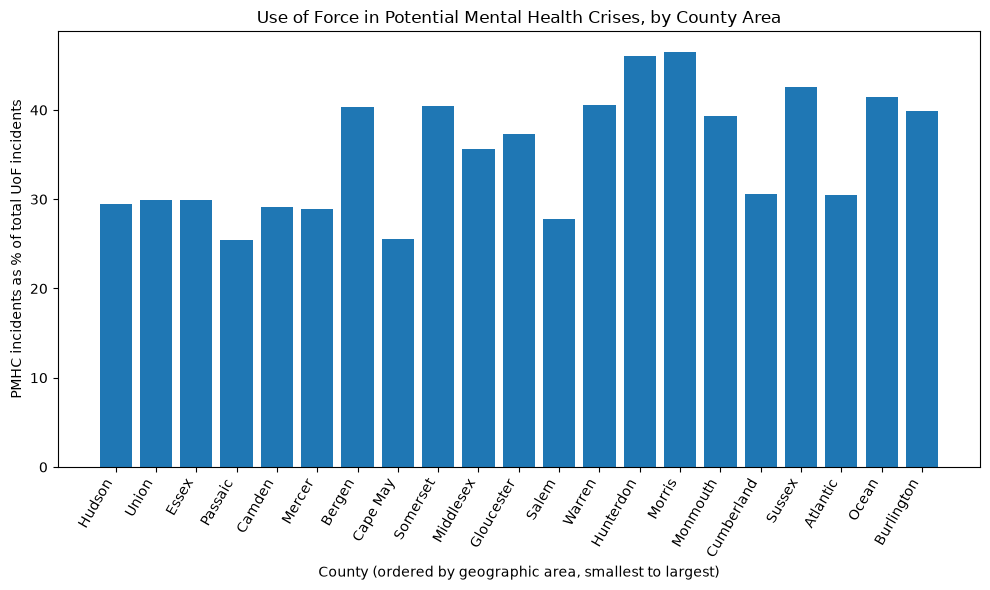

In [13]:
import matplotlib.pyplot as plt

county_summary_by_area = county_summary.sort_values("area_sq_mi")

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(county_summary_by_area["County"], county_summary_by_area["pmhc_pct"])
ax.set_ylabel("PMHC incidents as % of total UoF incidents")
ax.set_xlabel("County (ordered by geographic area, smallest to largest)")
ax.set_title("Use of Force in Potential Mental Health Crises, by County Area")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

### Step 8: Simple linear regression -- PMHC % vs. area

One straight line, fit with `numpy.polyfit` (no extra stats library needed). Still only 21 data points (one per county), so treat the fit as a rough trend line, not a rigorous model.

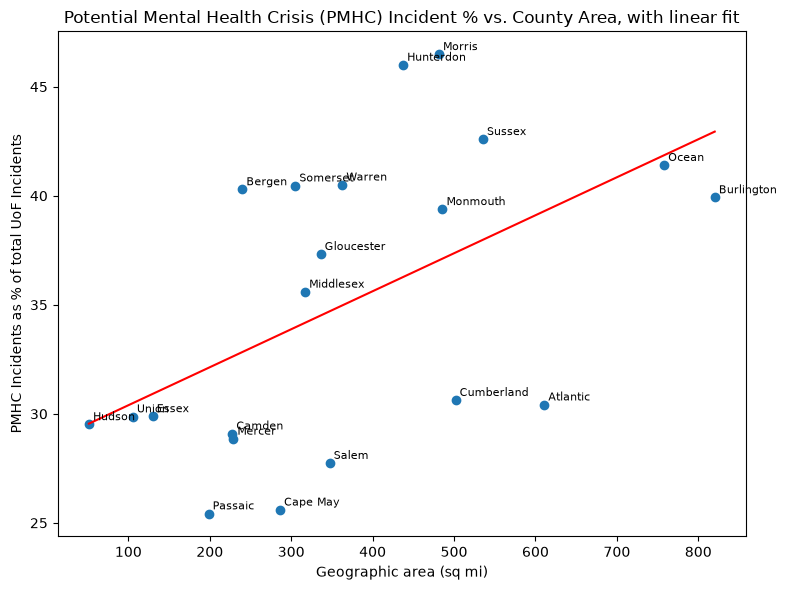

slope = 0.0174 pct points per sq mile
intercept = 28.65
r = 0.520, r-squared = 0.271


In [14]:
x = county_summary["area_sq_mi"].to_numpy()
y = county_summary["pmhc_pct"].to_numpy()

slope, intercept = np.polyfit(x, y, 1)
r = np.corrcoef(x, y)[0, 1]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x, y)
line_x = np.linspace(x.min(), x.max(), 100)
ax.plot(line_x, slope * line_x + intercept, color="red")
for _, row in county_summary.iterrows():
    ax.annotate(row["County"], (row["area_sq_mi"], row["pmhc_pct"]), fontsize=8, xytext=(3, 3), textcoords="offset points")
ax.set_xlabel("Geographic area (sq mi)")
ax.set_ylabel("PMHC Incidents as % of total UoF Incidents")
ax.set_title("Potential Mental Health Crisis (PMHC) Incident % vs. County Area, with linear fit")
plt.tight_layout()
plt.show()

print(f"slope = {slope:.4f} pct points per sq mile")
print(f"intercept = {intercept:.2f}")
print(f"r = {r:.3f}, r-squared = {r**2:.3f}")

## Findings: Does the data support the hypothesis?

**Partially.** The regression shows a positive slope (+0.017 PMHC percentage points per additional sq mi) with a moderate correlation of r = 0.520 (r² = 0.271) — larger counties do trend toward a higher PMHC share, in the direction the hypothesis predicts. But area only accounts for about 27% of the county-to-county variation, and this is only 21 data points (one per county), so treat this as a suggestive trend rather than a strong or conclusive relationship. It's a reasonable data point in favor of expanding ARRIVE Together in larger counties, but not strong enough on its own to justify that decision.

---
# Part 3: BIPOC Analysis — Use of Force Rate vs. Population Share

Hypothesis: BIPOC individuals make up a smaller share of a county's population but a *larger* share of the individuals subjected to Use of Force.

Data quirk worth flagging: `Subject_Race/Ethnicity` doesn't hold multiple race selections for one subject -- it holds **one race per subject involved**, comma-joined (e.g. `"Black or African American, Black or African American, White"` means three subjects, two Black and one White). So this is closer to `Force_Type`'s "one token per subject" pattern than to `Perceived_Condition`'s "multi-select for one thing" pattern.

We compare **% of UoF subjects who are BIPOC** to **% of county population who are BIPOC** -- counting individual people on both sides. An earlier version of this compared BIPOC *incidents* instead ("any subject in the incident is BIPOC"), but that one-sidedly inflates the incident-level number: a mixed incident with one BIPOC and one White subject counts entirely as BIPOC and never as non-BIPOC, so it isn't a fair comparison against a population percentage with no equivalent inflation. Counting subjects instead of incidents avoids that.

Plan:
1. Collapse rows to one row per `Incident_ID`, keeping one representative subject list per incident (same idea as the PMHC section's incident collapse -- multiple officers file separate reports for the same incident, and ~96% of the time they list an identical subject list anyway, so we just take the first).
2. Explode that subject list into one row per subject, and classify each as BIPOC / not BIPOC / unknown (`"Not Provided"` subjects are excluded individually, not as an all-or-nothing call for the whole incident).
3. Compute the BIPOC share of UoF subjects per county.
4. Compute the BIPOC share of each county's population from `community_profile_df`.
5. Combine into one table.
6. Grouped bar chart: population % vs. UoF subject % per county.

**Limitations worth stating plainly, rather than trying to fix with what we have:**
- Population share is a weak benchmark on its own -- it doesn't account for who police actually come into contact with (patrol patterns, call volume, arrest rates). The stronger comparison would be BIPOC UoF % vs. BIPOC *police encounter* %, but we only have UoF data, not encounter data, so we can't build that here.
- Age structure isn't controlled for -- if BIPOC and non-BIPOC populations have different age distributions, some of the population-vs-UoF gap could be an age artifact rather than a race one.
- We're assuming `"Not Provided"` has no racial pattern to it (i.e. it isn't disproportionately missing for any particular race or county) -- unverified, but a reasonable working assumption.

### Step 1: Collapse rows to unique incidents, keep one subject list per incident

Same `Incident_ID` collapsing idea as the PMHC/geography sections. Since ~96% of an incident's officer-report rows already list an identical `Subject_Race/Ethnicity` string, we just take the first row's value per incident rather than trying to reconcile disagreements.

In [15]:
incident_subjects_df = (
    uof_df.groupby("Incident_ID")
    .agg(County=("County", "first"), Subject_Race_Ethnicity=("Subject_Race/Ethnicity", "first"))
    .reset_index()
)

print(f"{len(uof_df)} officer-report rows collapse to {len(incident_subjects_df)} unique incidents")

104573 officer-report rows collapse to 55468 unique incidents


### Step 2: Explode into one row per subject, and classify

Each incident's subject list (e.g. `"Black or African American, White"`) becomes two rows, one per subject. `"Not Provided"` subjects are dropped individually rather than voiding the whole incident.

In [16]:
subjects_df = incident_subjects_df.assign(
    Subject_Race_Ethnicity=incident_subjects_df["Subject_Race_Ethnicity"].str.split(",")
).explode("Subject_Race_Ethnicity")
subjects_df["Subject_Race_Ethnicity"] = subjects_df["Subject_Race_Ethnicity"].str.strip()

known_subjects = subjects_df[subjects_df["Subject_Race_Ethnicity"].str.lower() != "not provided"].copy()
known_subjects["Is_BIPOC"] = known_subjects["Subject_Race_Ethnicity"].str.lower() != "white"

print(f"{len(subjects_df)} subject-instances, {len(subjects_df) - len(known_subjects)} with race 'Not Provided' (excluded)")

56173 subject-instances, 624 with race 'Not Provided' (excluded)


### Step 3: BIPOC share of UoF subjects per county

In [17]:
county_subject_counts = (
    known_subjects.groupby("County")
    .agg(total_subjects=("Is_BIPOC", "size"), bipoc_subjects=("Is_BIPOC", "sum"))
    .reset_index()
)
county_subject_counts["bipoc_pct"] = 100 * county_subject_counts["bipoc_subjects"] / county_subject_counts["total_subjects"]

county_subject_counts.sort_values("bipoc_pct", ascending=False)

,County,total_subjects,bipoc_subjects,bipoc_pct
6,Essex,7736,7087,91.610651
8,Hudson,4475,3824,85.452514
20,Union,2832,2374,83.827684
16,Passaic,3013,2482,82.376369
10,Mercer,2949,2422,82.129535
3,Camden,5463,4159,76.130331
5,Cumberland,2184,1648,75.457875
11,Middlesex,3433,2500,72.822604
15,Other,10,7,70.000000
0,Atlantic,2801,1840,65.690825


### Step 4: BIPOC share of population per county

`community_profile_df` reports `% White` per municipality as a string (e.g. `"63.00%"`), unconverted so far since earlier cells only needed the geography columns. BIPOC population % = 100% - `% White`, weighted by each municipality's population when rolled up to the county level (summing the raw population counts, not averaging the percentages, so bigger municipalities count for more).

In [18]:
white_pct = community_profile_df["% White"].str.rstrip("%").astype(float)
bipoc_population = community_profile_df["Population"] * (100 - white_pct) / 100

county_race_pop = (
    pd.DataFrame({
        "County": community_profile_df["County"],
        "population": community_profile_df["Population"],
        "bipoc_population": bipoc_population,
    })
    .groupby("County")
    .sum()
    .reset_index()
)
county_race_pop["bipoc_pop_pct"] = 100 * county_race_pop["bipoc_population"] / county_race_pop["population"]

county_race_pop.sort_values("bipoc_pop_pct", ascending=False)

,County,population,bipoc_population,bipoc_pop_pct
6,Essex,854130,615786.664,72.095192
8,Hudson,710478,510897.489,71.908981
19,Union,572549,364680.295,63.694163
11,Middlesex,861535,527613.051,61.241047
15,Passaic,518289,316783.167,61.120951
5,Cumberland,152915,88818.844,58.083801
10,Mercer,383286,213772.307,55.773576
17,Somerset,346203,171039.653,49.404440
1,Bergen,954717,453618.397,47.513388
3,Camden,524042,243935.331,46.548813


### Step 5: Combine into one table

In [19]:
county_race_summary = county_subject_counts.merge(county_race_pop, on="County", how="inner")
county_race_summary = county_race_summary.sort_values("bipoc_pop_pct", ascending=False).reset_index(drop=True)

dropped = set(county_subject_counts["County"]) - set(county_race_pop["County"])
print(f"Dropped (no population match): {dropped}")

county_race_summary[["County", "bipoc_pop_pct", "bipoc_pct", "bipoc_subjects", "total_subjects"]]

Dropped (no population match): {'Other'}


,County,bipoc_pop_pct,bipoc_pct,bipoc_subjects,total_subjects
0,Essex,72.095192,91.610651,7087,7736
1,Hudson,71.908981,85.452514,3824,4475
2,Union,63.694163,83.827684,2374,2832
3,Middlesex,61.241047,72.822604,2500,3433
4,Passaic,61.120951,82.376369,2482,3013
5,Cumberland,58.083801,75.457875,1648,2184
6,Mercer,55.773576,82.129535,2422,2949
7,Somerset,49.404440,62.973223,682,1083
8,Bergen,47.513388,64.563553,2108,3265
9,Camden,46.548813,76.130331,4159,5463


### Step 6: Population % vs. UoF subject % per county

Grouped bar chart, two bars per county. If the hypothesis holds, the "UoF subjects" bar should be taller than the "population" bar for most/all counties.

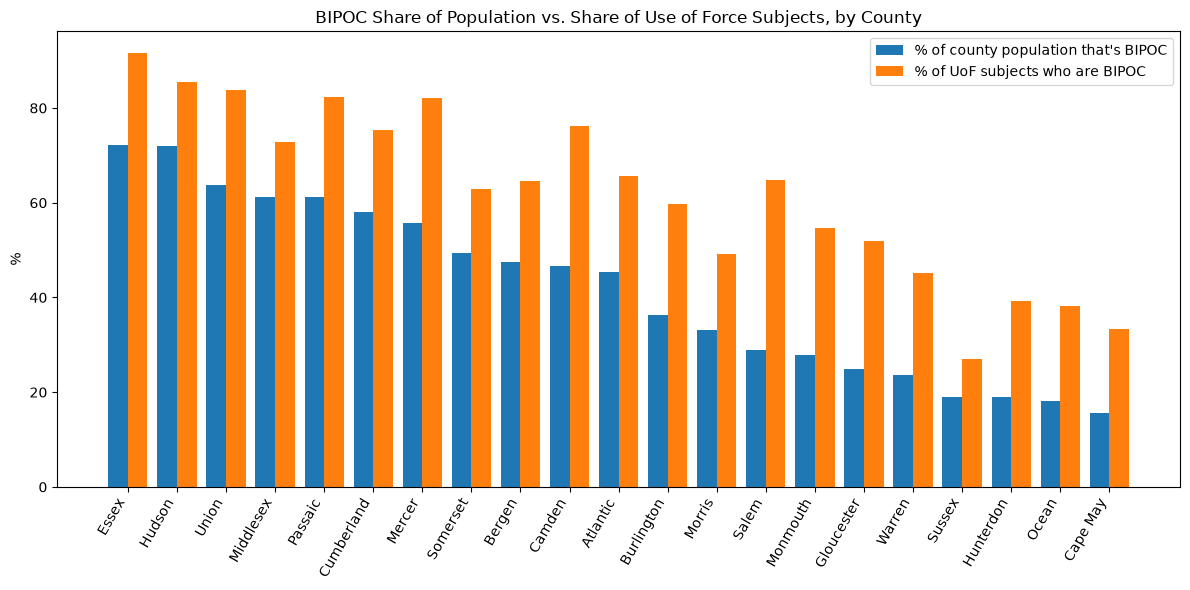

In [20]:
x = np.arange(len(county_race_summary))
width = 0.4

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width / 2, county_race_summary["bipoc_pop_pct"], width, label="% of county population that's BIPOC")
ax.bar(x + width / 2, county_race_summary["bipoc_pct"], width, label="% of UoF subjects who are BIPOC")
ax.set_xticks(x)
ax.set_xticklabels(county_race_summary["County"], rotation=60, ha="right")
ax.set_ylabel("%")
ax.set_title("BIPOC Share of Population vs. Share of Use of Force Subjects, by County")
ax.legend()
plt.tight_layout()
plt.show()

## Findings: Does the data support the hypothesis?

**Yes, clearly.** BIPOC subjects make up a larger share of UoF subjects than of the county population in **all 21 counties**, with no exceptions -- e.g. Salem County (29.0% BIPOC population vs. 64.9% of UoF subjects), Cape May (15.6% vs. 33.3%), and Essex (72.1% vs. 91.6%). The gap holds across the full range of counties, from the least to the most diverse. That said, the limitations noted above still apply -- population share alone doesn't establish *why* the gap exists (it could reflect differences in policing patterns, call volume, or who police actually come into contact with, none of which this data can isolate).

---
# Part 4: Urban vs. Suburban vs. Rural — Does the BIPOC Gap Vary by Community Type?

Hypothesis: in suburban municipalities, BIPOC subjects represent a higher proportion of UoF subjects relative to their local population share than in urban municipalities.

**Classifying municipalities**: split all 564 municipalities into thirds (tertiles) by population density (`Population / Square Miles`, computed directly from `community_profile_df` so the density and the race numbers come from the same source/year) -- bottom third = Rural, middle third = Suburban, top third = Urban. This is relative to NJ's own distribution: NJ is already dense by national standards, so this "Rural" tier would likely still read as urban/suburban by national norms. Worth stating plainly if this analysis is ever shared outside the project, but it's still a meaningful three-way split *within* NJ.

**Matching a UoF incident to a municipality**: `Incident_Municipality` (e.g. `"Hamilton, Atlantic County"`) and `community_profile_df`'s `Municipality` column (e.g. `"Hamilton Twp (Atlantic)"`) use different naming conventions. Importantly, `Incident_Municipality` *does* usually include a type suffix precisely when it's needed to disambiguate (e.g. `"Freehold township, Monmouth County"` vs. `"Freehold borough, Monmouth County"` are both real, separate municipalities, and the source data does distinguish them) -- so the matching below normalizes and uses that suffix when present, rather than discarding it, and only falls back to a bare-name match when the incident record itself doesn't include one. A handful of known historical renames (e.g. Ocean County's Dover Township was renamed Toms River Township in 2006, but some older incident records still say "Dover") are handled with a small alias table. This gets us to a 98.7% match rate; the rest is a mix of a few genuinely ambiguous bare names (e.g. plain `"Egg Harbor, Atlantic County"`, where Atlantic County has both an Egg Harbor City and an Egg Harbor Township and the record gives no way to tell which) and small scattered rows that look like county mis-entries in the source data (e.g. `"Newark, Union County"` -- Newark is in Essex) -- left excluded rather than guessed at.

Plan:
1. Classify municipalities into density tertiles.
2. Match each UoF row to a municipality (and therefore a tier).
3. Collapse to incidents and explode to subjects (same pattern as the county-level BIPOC section), grouped by tier instead of county.
4. BIPOC share of UoF subjects per tier.
5. BIPOC share of population per tier.
6. Combine, and plot two charts: population % vs. UoF % per tier, and the gap between them per tier.

### Step 1: Classify municipalities into density tertiles

In [21]:
community_profile_df["density"] = community_profile_df["Population"] / community_profile_df["Square Miles"]
community_profile_df["Tier"] = pd.qcut(community_profile_df["density"], 3, labels=["Rural", "Suburban", "Urban"])

community_profile_df.groupby("Tier", observed=True)["density"].agg(["count", "min", "max"])

,count,min,max
Tier,,,
Rural,188,0.000000,1071.500000
Suburban,188,1088.333333,3545.384615
Urban,188,3555.714286,58190.000000


### Step 2: Match each UoF row to a municipality

`split_name()` pulls the type suffix off the end of a name when one is present (handling the inconsistent casing/spelling -- `"township"`, `"Twp"`, `"Township"` all normalize to `"Twp"`) and leaves it alone otherwise. Matching then tries, in order: (1) base name + suffix + county -- the precise match, used whenever the incident record includes a suffix; (2) base name + county, only if that combination is unambiguous across all of `community_profile_df`; (3) the raw, unsplit name + county, which catches places like `"Surf City"` or `"Atlantic City"` where "City" is part of the actual name rather than a type suffix that should've been stripped.

In [22]:
import re
from collections import defaultdict

SUFFIX_MAP = {"township": "Twp", "twp": "Twp", "borough": "Boro", "boro": "Boro", "city": "City", "town": "Town", "village": "Village"}
SUFFIX_RE = re.compile(r"^(.*?)\s+(" + "|".join(SUFFIX_MAP.keys()) + r")\.?$", re.IGNORECASE)


def split_name(name):
    name = re.sub(r"\s*\([^)]*\)\s*$", "", name).strip()  # strip a trailing "(County)" annotation
    m = SUFFIX_RE.match(name)
    if m:
        return m.group(1).strip(), SUFFIX_MAP[m.group(2).lower()]
    return name, None


uof_df["_base_raw"] = uof_df["Incident_Municipality"].str.split(",").str[0].str.strip()
uof_df[["Base_Municipality", "Muni_Suffix"]] = uof_df["_base_raw"].apply(lambda n: pd.Series(split_name(n)))
community_profile_df[["Base_Municipality", "Muni_Suffix"]] = community_profile_df["Municipality"].apply(lambda n: pd.Series(split_name(n)))

# known historical renames / naming-format differences between the two datasets
def apply_rename(row):
    no_suffix = pd.isna(row["Muni_Suffix"])
    if row["County"] == "Ocean" and row["Base_Municipality"] == "Dover" and no_suffix:
        return pd.Series(["Toms River", "Twp"])
    if row["County"] == "Mercer" and row["Base_Municipality"] == "Washington" and no_suffix:
        return pd.Series(["Robbinsville", "Twp"])
    if row["County"] == "Passaic" and row["Base_Municipality"] == "West Paterson" and no_suffix:
        return pd.Series(["Woodland Park", "Boro"])
    if row["County"] == "Essex" and row["Base_Municipality"] == "Village of South Orange":
        return pd.Series(["South Orange Village", "Twp"])
    return pd.Series([row["Base_Municipality"], row["Muni_Suffix"]])


uof_df[["Base_Municipality", "Muni_Suffix"]] = uof_df.apply(apply_rename, axis=1)

# (base, suffix, county) -> exact match; (base, county) -> only kept if unambiguous
key_suffix = lambda v: None if pd.isna(v) else v
primary_lookup = {(r["Base_Municipality"], key_suffix(r["Muni_Suffix"]), r["County"]): idx for idx, r in community_profile_df.iterrows()}
base_groups = defaultdict(list)
for idx, r in community_profile_df.iterrows():
    base_groups[(r["Base_Municipality"], r["County"])].append(idx)
fallback_lookup = {k: v[0] for k, v in base_groups.items() if len(v) == 1}


def match_idx(row):
    k1 = (row["Base_Municipality"], key_suffix(row["Muni_Suffix"]), row["County"])
    if k1 in primary_lookup:
        return primary_lookup[k1]
    k2 = (row["Base_Municipality"], row["County"])
    if k2 in fallback_lookup:
        return fallback_lookup[k2]
    k3 = (row["_base_raw"], row["County"])
    return fallback_lookup.get(k3)


uof_df["cp_idx"] = uof_df.apply(match_idx, axis=1)
uof_df["Tier"] = uof_df["cp_idx"].map(community_profile_df["Tier"])

matched = uof_df["Tier"].notna().sum()
print(f"{matched} of {len(uof_df)} rows matched to a municipality/tier ({matched / len(uof_df):.1%})")

103257 of 104573 rows matched to a municipality/tier (98.7%)


### Step 3: Collapse to incidents, then explode to subjects

Same two-step pattern as the county-level BIPOC section: one row per `Incident_ID` (keeping the first row's `Tier` and subject list), then explode that subject list into one row per subject and classify each.

In [23]:
incident_tier_df = (
    uof_df.groupby("Incident_ID")
    .agg(Tier=("Tier", "first"), Subject_Race_Ethnicity=("Subject_Race/Ethnicity", "first"))
    .reset_index()
)

tier_subjects_df = incident_tier_df.assign(
    Subject_Race_Ethnicity=incident_tier_df["Subject_Race_Ethnicity"].str.split(",")
).explode("Subject_Race_Ethnicity")
tier_subjects_df["Subject_Race_Ethnicity"] = tier_subjects_df["Subject_Race_Ethnicity"].str.strip()

known_tier_subjects = tier_subjects_df[tier_subjects_df["Subject_Race_Ethnicity"].str.lower() != "not provided"].copy()
known_tier_subjects["Is_BIPOC"] = known_tier_subjects["Subject_Race_Ethnicity"].str.lower() != "white"
known_tier_subjects = known_tier_subjects.dropna(subset=["Tier"])

print(f"{len(known_tier_subjects)} subject-instances with a known race and a known tier")

54818 subject-instances with a known race and a known tier


### Step 4: BIPOC share of UoF subjects per tier

In [24]:
tier_subject_counts = (
    known_tier_subjects.groupby("Tier", observed=True)
    .agg(total_subjects=("Is_BIPOC", "size"), bipoc_subjects=("Is_BIPOC", "sum"))
    .reset_index()
)
tier_subject_counts["bipoc_pct"] = 100 * tier_subject_counts["bipoc_subjects"] / tier_subject_counts["total_subjects"]

tier_subject_counts

,Tier,total_subjects,bipoc_subjects,bipoc_pct
0,Rural,8647,4183,48.375159
1,Suburban,12701,6794,53.491851
2,Urban,33470,27521,82.225874


### Step 5: BIPOC share of population per tier

In [25]:
white_pct = community_profile_df["% White"].str.rstrip("%").astype(float)
community_profile_df["bipoc_population"] = community_profile_df["Population"] * (100 - white_pct) / 100

tier_pop = (
    community_profile_df.groupby("Tier", observed=True)
    .agg(population=("Population", "sum"), bipoc_population=("bipoc_population", "sum"))
    .reset_index()
)
tier_pop["bipoc_pop_pct"] = 100 * tier_pop["bipoc_population"] / tier_pop["population"]

tier_pop

,Tier,population,bipoc_population,bipoc_pop_pct
0,Rural,1813674,479703.573,26.449272
1,Suburban,2821619,1031454.375,36.555409
2,Urban,4631721,2942318.907,63.525392


### Step 6: Combine, ordered Rural -> Suburban -> Urban

In [26]:
tier_summary = tier_subject_counts.merge(tier_pop, on="Tier")

tier_order = pd.CategoricalDtype(["Rural", "Suburban", "Urban"], ordered=True)
tier_summary["Tier"] = tier_summary["Tier"].astype(tier_order)
tier_summary = tier_summary.sort_values("Tier").reset_index(drop=True)
tier_summary["gap"] = tier_summary["bipoc_pct"] - tier_summary["bipoc_pop_pct"]

tier_summary[["Tier", "bipoc_pop_pct", "bipoc_pct", "gap", "bipoc_subjects", "total_subjects"]]

,Tier,bipoc_pop_pct,bipoc_pct,gap,bipoc_subjects,total_subjects
0,Rural,26.449272,48.375159,21.925887,4183,8647
1,Suburban,36.555409,53.491851,16.936442,6794,12701
2,Urban,63.525392,82.225874,18.700482,27521,33470


### Step 7a: Population % vs. UoF subject % per tier

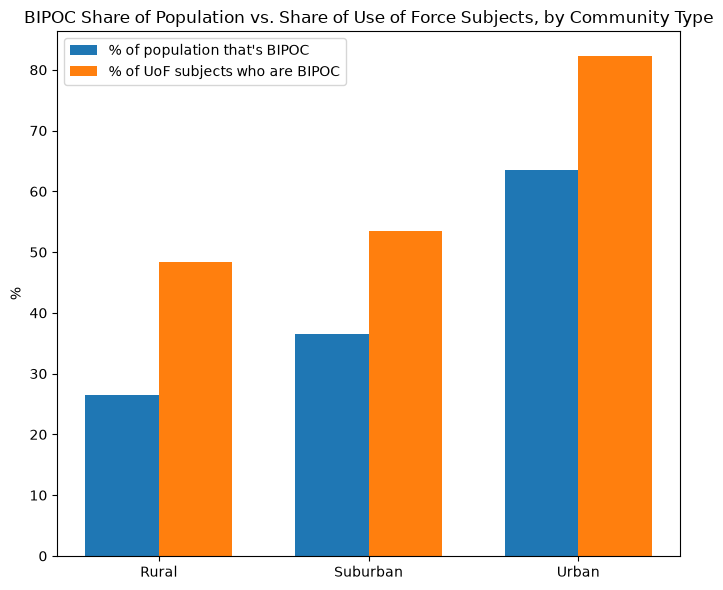

In [27]:
x = np.arange(len(tier_summary))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 6))
ax.bar(x - width / 2, tier_summary["bipoc_pop_pct"], width, label="% of population that's BIPOC")
ax.bar(x + width / 2, tier_summary["bipoc_pct"], width, label="% of UoF subjects who are BIPOC")
ax.set_xticks(x)
ax.set_xticklabels(tier_summary["Tier"])
ax.set_ylabel("%")
ax.set_title("BIPOC Share of Population vs. Share of Use of Force Subjects, by Community Type")
ax.legend()
plt.tight_layout()
plt.show()

### Step 7b: The gap itself (UoF % - population %) per tier

Isolates the disparity your hypothesis is actually about. If the hypothesis holds, Suburban's bar should be the tallest of the three.

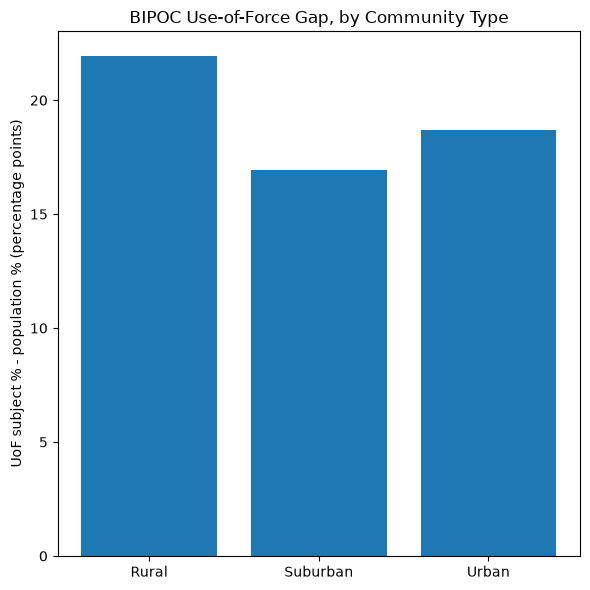

In [28]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.bar(tier_summary["Tier"].astype(str), tier_summary["gap"])
ax.set_ylabel("UoF subject % - population % (percentage points)")
ax.set_title("BIPOC Use-of-Force Gap, by Community Type")
plt.tight_layout()
plt.show()

## Findings: Does the data support the hypothesis?

**No.** The hypothesis predicted the Suburban gap would be the largest of the three tiers -- instead it's the *smallest* (16.9 points), while Rural has the largest gap (21.9 points) and Urban falls in between (18.7 points). The BIPOC-vs-population gap clearly exists in every tier (consistent with the county-level finding above), but it doesn't vary by community type the way the hypothesis expected -- if anything, being a racial minority in a low-density (Rural) area shows the widest gap here, not a mid-density (Suburban) one.